# Notebook 01 — BERTopic Topic Modelling

**Goal:** Run unsupervised topic discovery on the 278 decision-making responses and measure how well discovered topics align with the 5 qualitative codes.

**Research question:** If NLP has no knowledge of the HSE consent framework codes, does it independently discover the same thematic structure that qualitative researchers found?

**Pipeline:**
```
Sentence-BERT embeddings (GPU)
    → UMAP dimensionality reduction
    → HDBSCAN clustering
    → c-TF-IDF topic labels
    → Compare vs 5 qualitative codes (NMI, ARI)
    → Guided BERTopic run (seeded with code definitions)
```

**GPU notes (RTX 4060 Laptop):**  
Sentence-BERT encoding uses the GPU. UMAP and HDBSCAN run on CPU (no CUDA kernels available in standard distributions). With n=278 this is fast either way.

## 0. Load config and data

In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')  # prevent OpenMP duplicate-runtime segfault (torch+MKL/numba)

import pickle, pathlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
warnings.filterwarnings('ignore')

DATA_DIR   = pathlib.Path('data')
OUTPUT_DIR = pathlib.Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

with open(DATA_DIR / 'config.pkl', 'rb') as f:
    cfg = pickle.load(f)

DECISION_CODES   = cfg['DECISION_CODES']
CODE_DEFINITIONS = cfg['CODE_DEFINITIONS']
DEVICE           = cfg['DEVICE']
SEED             = cfg['SEED']

dm_df  = pd.read_csv(DATA_DIR / 'decision_making.csv')
exp_df = pd.read_csv(DATA_DIR / 'experience.csv')

DOCS   = dm_df['response_text'].tolist()
LABELS = dm_df['label'].values
CODE_NAMES = list(DECISION_CODES.keys())

print(f'Decision-making responses: {len(DOCS)}')
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM free: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB')

Decision-making responses: 278
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM free: 7.5 GB


## 1. Sentence-BERT embeddings (GPU-accelerated)

In [2]:
from sentence_transformers import SentenceTransformer
import time

# ── Model choice rationale ─────────────────────────────────────────────────────
# all-mpnet-base-v2        : 768-d, established general-purpose baseline
# bge-base-en-v1.5         : 768-d, strong on MTEB clustering
# mxbai-embed-large-v1     : 1024-d, top clustering quality for its size
# We run both and keep both embedding matrices.
# RTX 4060: both fit in VRAM with FP16

EMBEDDING_MODELS = {
    'mpnet': 'sentence-transformers/all-mpnet-base-v2',   # 768-d, established, no prefix
    'bge':   'BAAI/bge-base-en-v1.5',                      # 768-d, strong clustering
    'mxbai': 'mixedbread-ai/mxbai-embed-large-v1',         # 1024-d, top small-model clustering
}

embeddings_cache = {}

for name, model_id in EMBEDDING_MODELS.items():
    print(f'\nEncoding with {model_id}...')
    t0 = time.time()

    embedder = SentenceTransformer(model_id, device=DEVICE)

    # FP16 on GPU — halves VRAM usage with negligible quality loss
    if DEVICE == 'cuda':
        embedder = embedder.half()

    embs = embedder.encode(
        DOCS,
        batch_size=64,             # RTX 4060 handles 64 comfortably
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True, # cosine distance == dot product after this
    )

    # Cast back to float32 for sklearn/UMAP compatibility
    embs = embs.astype(np.float32)
    embeddings_cache[name] = embs

    print(f'  Shape: {embs.shape}  |  Time: {time.time()-t0:.1f}s')

    # Free GPU memory between models
    del embedder
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()

# Use mpnet as primary (richer semantics), minilm as fast alternative
# Choose which embedding drives the main BERTopic run
PRIMARY_KEY = 'bge'          # 'mpnet' | 'bge' | 'mxbai'
PRIMARY_EMBEDDINGS = embeddings_cache[PRIMARY_KEY]
print(f'\nPrimary = {PRIMARY_KEY}  |  shape: {PRIMARY_EMBEDDINGS.shape}')

# Save every embedding matrix for later notebooks
for _name, _arr in embeddings_cache.items():
    np.save(DATA_DIR / f'embeddings_{_name}.npy', _arr)
print('Embeddings saved:', ', '.join(f'embeddings_{k}.npy' for k in embeddings_cache))


Encoding with sentence-transformers/all-mpnet-base-v2...


Batches: 100%|██████████| 5/5 [00:01<00:00,  4.32it/s]


  Shape: (278, 768)  |  Time: 4.7s

Encoding with BAAI/bge-base-en-v1.5...


Batches: 100%|██████████| 5/5 [00:00<00:00,  7.72it/s]


  Shape: (278, 768)  |  Time: 3.9s

Encoding with mixedbread-ai/mxbai-embed-large-v1...


Batches: 100%|██████████| 5/5 [00:01<00:00,  3.87it/s]

  Shape: (278, 1024)  |  Time: 5.6s

Primary = bge  |  shape: (278, 768)
Embeddings saved: embeddings_mpnet.npy, embeddings_bge.npy, embeddings_mxbai.npy


## 2. BERTopic — unsupervised run

In [3]:
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# ── Component config ──────────────────────────────────────────────────────────
# UMAP: small n_neighbors for small dataset; cosine metric (matches normalised embs)
umap_model = UMAP(
    n_neighbors=5,
    n_components=5,
    min_dist=0.0,
    metric='cosine',
    random_state=SEED,
    low_memory=False,
)

# HDBSCAN: min_cluster_size=4 allows discovery of rare codes (no_consent n=8)
hdbscan_model = HDBSCAN(
    min_cluster_size=4,
    min_samples=2,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True,
)

# Vectoriser: bigrams catch phrases like 'no choice', 'dead baby card'
vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=1,
)

# Representation: MaximalMarginalRelevance reduces redundancy in keywords
representation = MaximalMarginalRelevance(diversity=0.3)

topic_model_unsupervised = BERTopic(
    umap_model           = umap_model,
    hdbscan_model        = hdbscan_model,
    vectorizer_model     = vectorizer,
    representation_model = representation,
    top_n_words          = 12,
    verbose              = True,
)

print('Fitting unsupervised BERTopic...')
topics_unsup, probs_unsup = topic_model_unsupervised.fit_transform(
    DOCS, PRIMARY_EMBEDDINGS
)
topics_unsup = np.array(topics_unsup)

info = topic_model_unsupervised.get_topic_info()
n_topics   = len(info[info['Topic'] != -1])
n_outliers = (topics_unsup == -1).sum()
print(f'\nDiscovered {n_topics} topics  |  {n_outliers} outliers ({n_outliers/len(DOCS)*100:.0f}%)')

2026-07-15 16:51:29,657 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Fitting unsupervised BERTopic...


2026-07-15 16:51:37,875 - BERTopic - Dimensionality - Completed ✓
2026-07-15 16:51:37,875 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-15 16:51:37,885 - BERTopic - Cluster - Completed ✓
2026-07-15 16:51:37,889 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-15 16:51:37,930 - BERTopic - Representation - Completed ✓



Discovered 24 topics  |  23 outliers (8%)


In [4]:
# ── Display topic keywords ────────────────────────────────────────────────────
print('\n── Discovered topics and their top keywords ──\n')
topic_info = topic_model_unsupervised.get_topic_info()
topic_info_clean = topic_info[topic_info['Topic'] != -1].copy()

for _, row in topic_info_clean.iterrows():
    tid   = row['Topic']
    count = row['Count']
    words = [w for w, _ in topic_model_unsupervised.get_topic(tid)[:10]]
    print(f'  Topic {tid:3d}  ({count:3d} docs): {", ".join(words)}')

print(f'\n  Outliers (topic -1): {(topics_unsup == -1).sum()} docs not assigned to any cluster')


── Discovered topics and their top keywords ──

  Topic   0  ( 31 docs): positive, happy, positive experience, experience, didnt, second, inductions, sweep, positive experiences, birth
  Topic   1  ( 30 docs): sweep, induction, didnt, asked, did, said, want, like, weeks, felt
  Topic   2  ( 18 docs): information, given, doesnt work, doesnt, 10, information given, inductions, induction, needs, failed induction
  Topic   3  ( 16 docs): felt, labour, waters, naturally, broken, wish, bit, labour naturally, waters broken, uncomfortable
  Topic   4  ( 16 docs): waters, pain, ward, labour, broken, labour ward, waters broken, birth, breaking, hours
  Topic   5  ( 15 docs): women, forced, irish, just, theyre, hospitals, offered, mothers, forced women, women vulnerable
  Topic   6  ( 15 docs): midwife, felt, midwives, alternative, hospital, date, doctor, asked, told, tie
  Topic   7  ( 11 docs): gel, section, pessary, contractions, heart rate, removed, heart, dilate, induced, induction
  Topic 

In [5]:
# ── Alignment: do discovered topics line up with the qualitative codes? ───────
from sklearn.metrics import (normalized_mutual_info_score, adjusted_rand_score,
                             homogeneity_completeness_v_measure)

label_to_name = {v: k for k, v in DECISION_CODES.items()}

def alignment_metrics(topics, labels):
    """Compare a topic assignment to the human codes (outliers, topic == -1, excluded)."""
    topics = np.asarray(topics); labels = np.asarray(labels)
    keep = topics != -1
    t, c = topics[keep], labels[keep]
    h, comp, v = homogeneity_completeness_v_measure(c, t)
    return {
        'n_topics':     int(len(set(t))),
        'outlier_pct':  float((topics == -1).mean() * 100),
        'nmi':          normalized_mutual_info_score(c, t),
        'ari':          adjusted_rand_score(c, t),
        'homogeneity':  h,      # is each topic internally one code? (fair to fine-grained topics)
        'completeness': comp,   # is each code gathered into a single topic?
        'v_measure':    v,      # harmonic mean of homogeneity and completeness
    }

m_unsup = alignment_metrics(topics_unsup, LABELS)
nmi, ari = m_unsup['nmi'], m_unsup['ari']     # keep the names used by later cells

print('── Unsupervised BERTopic vs qualitative codes ──')
print(f"  topics discovered : {m_unsup['n_topics']}   (vs 5 human codes)")
print(f"  outliers          : {m_unsup['outlier_pct']:.0f}%")
print(f"  NMI               : {m_unsup['nmi']:.3f}   (0 = random, 1 = identical)")
print(f"  ARI               : {m_unsup['ari']:.3f}   (heavily penalised by the topic-count gap)")
print(f"  homogeneity       : {m_unsup['homogeneity']:.3f}   (are discovered topics code-pure?)")
print(f"  completeness      : {m_unsup['completeness']:.3f}   (is each code kept in one topic?)")
print(f"  V-measure         : {m_unsup['v_measure']:.3f}")

# ── Which qualitative code dominates each discovered topic? ───────────────────
mask = topics_unsup != -1
rows = []
for t in sorted(set(topics_unsup[mask])):
    codes = LABELS[mask][topics_unsup[mask] == t]
    vc = pd.Series(codes).value_counts()
    rows.append({'topic': int(t), 'size': int(len(codes)),
                 'dominant_code': label_to_name[int(vc.idxmax())],
                 'purity': round(float(vc.iloc[0] / len(codes)), 2)})
topic_map = pd.DataFrame(rows)

# If each topic were relabelled as its dominant code, how many docs land on the right code?
dom = {r['topic']: r['dominant_code'] for _, r in topic_map.iterrows()}
mapped_acc = float(np.mean([dom[int(t)] == label_to_name[int(c)]
                            for t, c in zip(topics_unsup[mask], LABELS[mask])]))

print(f'\nTopic -> dominant-code "mapped accuracy" (non-outliers): {mapped_acc:.2f}')
print('\nPer-topic dominant code and purity:')
print(topic_map.to_string(index=False))

# ── Cross-tabulation (rows = human code, cols = discovered topic) ─────────────
ct = pd.crosstab(
    pd.Series(LABELS[mask]).map(label_to_name).rename('Qualitative code'),
    pd.Series(topics_unsup[mask]).rename('BERTopic topic'),
)
print('\nCross-tabulation (rows=human code, cols=discovered topic):')
display(ct)

── Unsupervised BERTopic vs qualitative codes ──
  topics discovered : 24   (vs 5 human codes)
  outliers          : 8%
  NMI               : 0.168   (0 = random, 1 = identical)
  ARI               : 0.014   (heavily penalised by the topic-count gap)
  homogeneity       : 0.292   (are discovered topics code-pure?)
  completeness      : 0.117   (is each code kept in one topic?)
  V-measure         : 0.168

Topic -> dominant-code "mapped accuracy" (non-outliers): 0.61

Per-topic dominant code and purity:
 topic  size      dominant_code  purity
     0    31 voluntary_informed    0.42
     1    30  insufficient_info    0.30
     2    18  insufficient_info    0.89
     3    16  feeling_pressured    0.56
     4    16  insufficient_info    0.75
     5    15  feeling_pressured    0.53
     6    15  feeling_pressured    0.67
     7    11  insufficient_info    0.73
     8    11  insufficient_info    0.64
     9    10  insufficient_info    0.60
    10    10  feeling_pressured    0.60
    11     8

BERTopic topic,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
Qualitative code,,,,,,,,,,,,,,,,,,,,,
feeling_pressured,5,8,1,9,3,8,10,1,2,2,...,1,3,2,1,3,0,0,0,2,0
insufficient_info,11,9,16,5,12,7,4,8,7,6,...,5,2,4,2,1,5,1,5,2,2
no_consent,0,5,0,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
too_much_info,2,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,4,0,0,2
voluntary_informed,13,8,1,1,0,0,1,2,2,1,...,0,1,0,1,1,0,0,0,0,0


In [6]:
# ── Parameter sensitivity: how do topic count / outliers / alignment shift? ───
# HDBSCAN auto-decides the topic count from density — we never set it directly.
# These are the biggest levers. Params chosen a priori (NOT tuned to the labels):
# use this to report robustness, not to pick the row with the best NMI.
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.representation import MaximalMarginalRelevance

sweep_rows = []
for nn in [5, 10, 15]:
    for mcs in [4, 8, 15]:
        tm = BERTopic(
            umap_model=UMAP(n_neighbors=nn, n_components=5, min_dist=0.0,
                            metric='cosine', random_state=SEED),
            hdbscan_model=HDBSCAN(min_cluster_size=mcs, min_samples=1,
                                  metric='euclidean', cluster_selection_method='eom'),
            vectorizer_model=CountVectorizer(stop_words='english', ngram_range=(1, 2), min_df=1),
            representation_model=MaximalMarginalRelevance(diversity=0.3),
            verbose=False)
        tps = np.array(tm.fit_transform(DOCS, PRIMARY_EMBEDDINGS)[0])
        m = alignment_metrics(tps, LABELS)
        sweep_rows.append({'n_neighbors': nn, 'min_cluster_size': mcs,
                           'n_topics': m['n_topics'],
                           'outlier_%': round(m['outlier_pct']),
                           'NMI': round(m['nmi'], 3),
                           'homogeneity': round(m['homogeneity'], 3),
                           'completeness': round(m['completeness'], 3)})

sweep_df = pd.DataFrame(sweep_rows)
print('Sensitivity — UMAP n_neighbors x HDBSCAN min_cluster_size:\n')
print(sweep_df.to_string(index=False))

Sensitivity — UMAP n_neighbors x HDBSCAN min_cluster_size:

 n_neighbors  min_cluster_size  n_topics  outlier_%   NMI  homogeneity  completeness
           5                 4        32          9 0.183        0.346         0.125
           5                 8        13          3 0.149        0.232         0.110
           5                15        11          6 0.140        0.208         0.106
          10                 4        34         13 0.213        0.417         0.143
          10                 8         8          3 0.122        0.132         0.113
          10                15         2          0 0.074        0.058         0.104
          15                 4        30         15 0.213        0.410         0.144
          15                 8        16         17 0.188        0.306         0.135
          15                15         2          0 0.085        0.066         0.119


Computing 2D UMAP for visualisation...


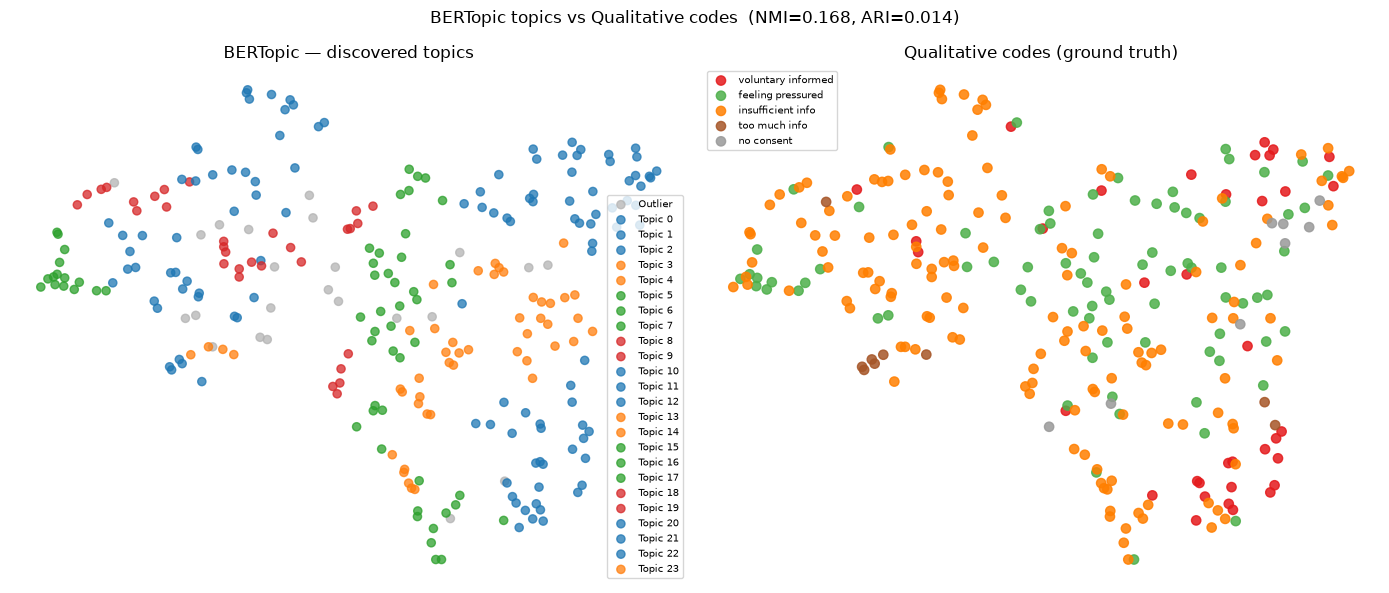

In [7]:
# ── UMAP 2D visualisation ─────────────────────────────────────────────────────
from umap import UMAP as UMAP2D

print('Computing 2D UMAP for visualisation...')
umap_2d = UMAP2D(n_components=2, n_neighbors=5, min_dist=0.1,
                  metric='cosine', random_state=SEED)
xy = umap_2d.fit_transform(PRIMARY_EMBEDDINGS)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
palette_topic = plt.cm.tab10(np.linspace(0, 1, max(topics_unsup) + 2))
palette_code  = plt.cm.Set1(np.linspace(0, 0.9, len(CODE_NAMES)))

# Left: BERTopic coloured
for tid in sorted(set(topics_unsup)):
    mask_t = topics_unsup == tid
    color  = [0.7, 0.7, 0.7, 0.4] if tid == -1 else palette_topic[tid % 10]
    label  = 'Outlier' if tid == -1 else f'Topic {tid}'
    axes[0].scatter(xy[mask_t, 0], xy[mask_t, 1], c=[color]*mask_t.sum(),
                    s=35, alpha=0.75, label=label)
axes[0].set_title('BERTopic — discovered topics')
axes[0].legend(fontsize=7, loc='best')
axes[0].axis('off')

# Right: qualitative codes
for i, code in enumerate(CODE_NAMES):
    mask_c = LABELS == i
    axes[1].scatter(xy[mask_c, 0], xy[mask_c, 1],
                    c=[palette_code[i]]*mask_c.sum(),
                    s=45, alpha=0.85, label=code.replace('_', ' '))
axes[1].set_title('Qualitative codes (ground truth)')
axes[1].legend(fontsize=7, loc='best')
axes[1].axis('off')

plt.suptitle(f'BERTopic topics vs Qualitative codes  (NMI={nmi:.3f}, ARI={ari:.3f})',
             fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'bertopic_umap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Representation-seeded BERTopic (keyword steering only — *not* a re-clustering)

`seed_topic_list` boosts the listed terms inside each topic's keyword description. It does **not** change how documents are grouped (UMAP → HDBSCAN), so the document-to-topic assignments — and therefore every alignment metric (NMI / ARI / V-measure) — are **identical to the unsupervised run by construction**.

In [8]:
# ── Representation-seeded BERTopic ─────────────────────────────────────────────
# NOTE: seed_topic_list only re-weights each topic's c-TF-IDF *keywords*. It does
# NOT alter the UMAP+HDBSCAN clustering, so topic assignments (and thus the alignment
# metrics) are identical to the unsupervised run *by design*. We keep it only to
# inspect whether the seeded keywords read more clearly.
seed_topic_list = [
    # voluntary_informed
    ['informed', 'voluntary', 'explained', 'choice', 'supported',
     'alternatives', 'risks benefits', 'well informed', 'decision'],
    # feeling_pressured
    ['pressured', 'forced', 'threatened', 'coerced', 'bullied',
     'scared', 'fearmongering', 'no choice', 'wore down', 'pushed'],
    # insufficient_info
    ['no information', 'not told', 'risks not explained', 'no consent',
     'not informed', 'didn\'t know', 'unaware', 'no discussion'],
    # too_much_info
    ['too much', 'anxiety', 'scared', 'horror stories', 'negative stories',
     'fear', 'worried', 'overwhelmed'],
    # no_consent
    ['without consent', 'without asking', 'without permission', 'not asked',
     'sweep without', 'drip without', 'birth plan ignored'],
]

umap_guided = UMAP(n_neighbors=5, n_components=5, min_dist=0.0,
                    metric='cosine', random_state=SEED)
hdbscan_guided = HDBSCAN(min_cluster_size=4, min_samples=2,
                          metric='euclidean', cluster_selection_method='eom',
                          prediction_data=True)

topic_model_guided = BERTopic(
    umap_model           = umap_guided,
    hdbscan_model        = hdbscan_guided,
    vectorizer_model     = CountVectorizer(stop_words='english', ngram_range=(1, 2), min_df=1),
    representation_model = MaximalMarginalRelevance(diversity=0.3),
    seed_topic_list      = seed_topic_list,
    top_n_words          = 12,
    verbose              = True,
)

print('Fitting representation-seeded BERTopic...')
topics_guided, probs_guided = topic_model_guided.fit_transform(DOCS, PRIMARY_EMBEDDINGS)
topics_guided = np.array(topics_guided)

# Confirm the clustering is unchanged vs the unsupervised run (expected: True)
m_guided = alignment_metrics(topics_guided, LABELS)
nmi_g, ari_g = m_guided['nmi'], m_guided['ari']
identical = np.array_equal(topics_guided, topics_unsup)
print(f'\nCluster assignments identical to unsupervised run: {identical}')
print(f'(Seeding changes keywords, not clusters — metrics unchanged by design: '
      f'NMI={nmi_g:.3f}, V-measure={m_guided["v_measure"]:.3f})')

print('\nSeeded topic keywords:')
for _, row in topic_model_guided.get_topic_info().iterrows():
    tid = row['Topic']
    if tid == -1:
        continue
    words = [w for w, _ in topic_model_guided.get_topic(tid)[:10]]
    print(f'  Topic {tid}: {", ".join(words)}')

2026-07-15 16:51:42,309 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Fitting representation-seeded BERTopic...


2026-07-15 16:51:42,548 - BERTopic - Dimensionality - Completed ✓
2026-07-15 16:51:42,548 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-15 16:51:42,554 - BERTopic - Cluster - Completed ✓
2026-07-15 16:51:42,557 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-15 16:51:42,582 - BERTopic - Representation - Completed ✓



Cluster assignments identical to unsupervised run: True
(Seeding changes keywords, not clusters — metrics unchanged by design: NMI=0.168, V-measure=0.168)

Seeded topic keywords:
  Topic 0: positive, happy, positive experience, experience, didnt, second, informed, inductions, sweep, positive experiences
  Topic 1: sweep, induction, didnt, asked, did, said, want, like, weeks, felt
  Topic 2: information, given, doesnt work, doesnt, 10, information given, inductions, induction, needs, failed induction
  Topic 3: felt, labour, waters, naturally, broken, wish, bit, labour naturally, waters broken, uncomfortable
  Topic 4: waters, pain, ward, labour, broken, labour ward, waters broken, birth, breaking, hours
  Topic 5: women, forced, irish, just, theyre, hospitals, offered, pushed, mothers, irish hospitals
  Topic 6: midwife, felt, midwives, alternative, hospital, date, doctor, asked, pushed, told
  Topic 7: gel, section, pessary, contractions, heart rate, removed, heart, dilate, induced, 

## 4. Topic keyword heatmap vs qualitative codes

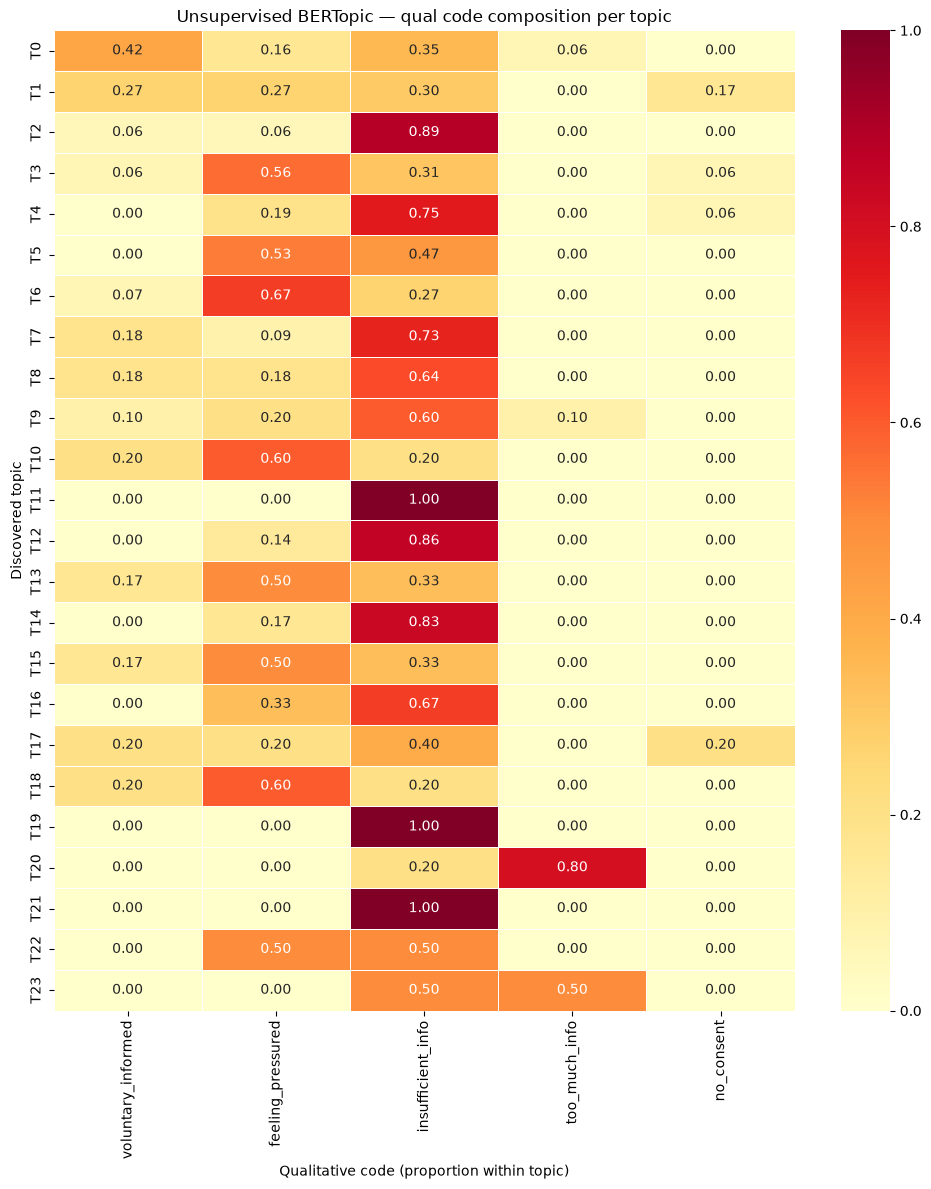

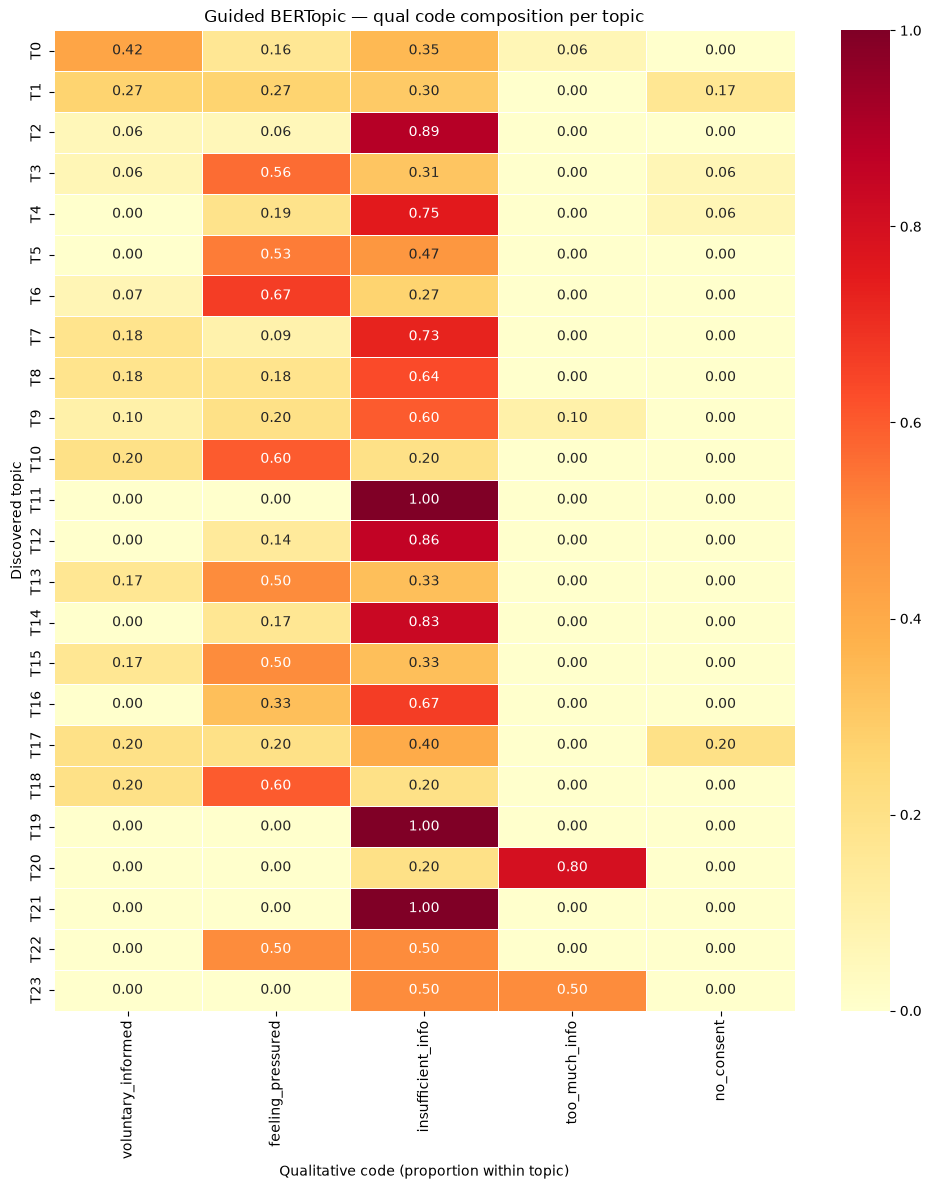

In [9]:
# ── Heatmap: proportion of each qual code in each discovered topic ────────────
def topic_code_heatmap(topics, labels, code_names, title, save_name):
    mask   = topics != -1
    df_tmp = pd.DataFrame({'topic': topics[mask], 'code': labels[mask]})
    n_topics_local = df_tmp['topic'].nunique()
    if n_topics_local == 0:
        print('No non-outlier documents to plot.')
        return
    ct = pd.crosstab(df_tmp['topic'], df_tmp['code'],
                     rownames=['Topic'], colnames=['Code'], normalize='index')
    ct.columns = [code_names[c] for c in ct.columns]
    ct.index   = [f'T{t}' for t in ct.index]

    fig, ax = plt.subplots(figsize=(10, max(3, n_topics_local * 0.5)))
    sns.heatmap(ct, annot=True, fmt='.2f', cmap='YlOrRd',
                linewidths=0.4, ax=ax, vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel('Qualitative code (proportion within topic)')
    ax.set_ylabel('Discovered topic')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / save_name, dpi=150, bbox_inches='tight')
    plt.show()

topic_code_heatmap(topics_unsup, LABELS, CODE_NAMES,
                   'Unsupervised BERTopic — qual code composition per topic',
                   'bertopic_unsup_heatmap.png')

topic_code_heatmap(topics_guided, LABELS, CODE_NAMES,
                   'Guided BERTopic — qual code composition per topic',
                   'bertopic_guided_heatmap.png')

## 5. Save BERTopic outputs

In [ ]:
import pickle

topic_assignments = dm_df[['response_id', 'source_row_id']].copy()
topic_assignments['bertopic_unsup'] = np.asarray(topics_unsup, dtype=int)
topic_assignments['bertopic_guided'] = np.asarray(topics_guided, dtype=int)
topic_assignments.to_csv(DATA_DIR / 'bertopic_assignments.csv', index=False)

assignments_identical = bool(np.array_equal(np.asarray(topics_unsup), np.asarray(topics_guided)))
bertopic_results = {
    'topics_unsupervised': np.asarray(topics_unsup),
    'topics_guided': np.asarray(topics_guided),
    'nmi_unsup': nmi, 'ari_unsup': ari,
    'nmi_guided': nmi_g, 'ari_guided': ari_g,
    'metrics_unsup': m_unsup, 'metrics_guided': m_guided,
    'primary_embedder': PRIMARY_KEY,
    'topic_code_map': topic_map,
    'mapped_accuracy': mapped_acc,
    'assignment_join_key': 'response_id',
    'guided_assignments_identical_to_unsupervised': assignments_identical,
    'guided_variant_role': 'representation-only keyword steering; not a second clustering result' if assignments_identical else 'assignment-changing variant',
}
with open(DATA_DIR / 'bertopic_results.pkl', 'wb') as f:
    pickle.dump(bertopic_results, f)

print(f'Saved ID-keyed topic assignments: {DATA_DIR / "bertopic_assignments.csv"}')
print(f'Guided assignments identical to unsupervised: {assignments_identical}')
print('Notebook 00 base data was not overwritten.')
